In [1]:
import model_loader
import pipeline
from transformers import CLIPTokenizer
import torch
from PIL import Image

DEVICE = "cpu"
ALLOW_CUDA = False
ALLOW_MPS = False

if torch.cuda.is_available() and ALLOW_CUDA:
   DEVICE = "cuda"
elif (torch.has_mps or torch.backends.mps.is_available()) and ALLOW_MPS:
   DEVICE = "mps"
print(f"Using device: {DEVICE}")

# Set precision to float16 for CUDA to double the speed
PRECISION = torch.float16 if DEVICE == "cuda" else torch.float32
print(f"Using precision: {PRECISION}")

Using device: cpu
Using precision: torch.float32


C:\Users\visha\AppData\Local\Temp\ipykernel_19440\51337689.py:13: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  elif (torch.has_mps or torch.backends.mps.is_available()) and ALLOW_MPS:


In [2]:
tokenizer = CLIPTokenizer("data/vocab.json", merges_file="data/merges.txt")
model_File = "data/v1-5-pruned-emaonly.safetensors"

models = model_loader.preload_models_from_standard_weights(model_File, device=DEVICE, precision=PRECISION)

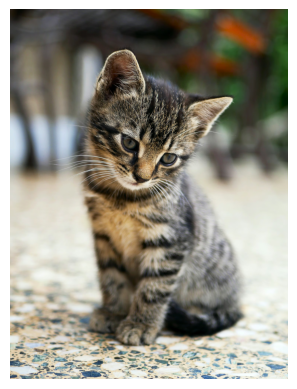

In [3]:
# Text to image
prompt = "A cat stretching on the floor, highly detailed, ultra sharp, cinematic, 8k resolution"
neg_prompt = "White fur or coat or colored skin"
do_cfg = True
cfg_scale = 7

# Image to Image
image_path = "Image/cat.avif"
input_image = Image.open(image_path)

# input_image.show() ## For OS default viewer
import matplotlib.pyplot as plt

plt.imshow(input_image)
plt.axis("off")  # Hide axes
plt.show()

In [4]:
## Model run
strength = 0.9
sampler = "ddpm"
num_inference_steps = 25
seed = 42

output_image = pipeline.generate(prompt, neg_prompt, input_image=input_image,
	strength=strength, do_cfg=do_cfg, cfg_scale=cfg_scale,
	sampler_name=sampler, n_inference_step=num_inference_steps, 
	seed=seed, models=models, device=DEVICE, idle_device="cpu",
	tokenizer=tokenizer, precision=PRECISION
)

100%|██████████| 22/22 [01:03<00:00,  2.88s/it]


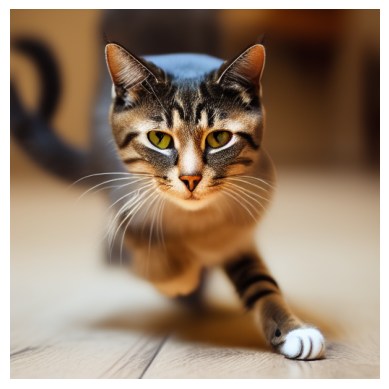

In [5]:
plt.imshow(output_image)
plt.axis("off")  # Hide axes
plt.show()